In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib as mpl
import seaborn as sns
from matplotlib.colors import LogNorm
from matplotlib.cm import ScalarMappable
from scipy.stats import fisher_exact
from statsmodels.stats.multitest import multipletests
import warnings

warnings.simplefilter('ignore')
plt.rcParams.update({
    'font.family': 'Arial',
    'font.size': 7,
    'axes.titlesize': 7,
    'axes.labelsize': 7,
    'xtick.labelsize': 7,
    'ytick.labelsize': 7,
    'legend.fontsize': 7,
    'figure.titlesize': 7,
    'figure.dpi': 200,
    'axes.linewidth': 0.7,
    'pdf.fonttype': 42,
    'ps.fonttype': 42,
})

In [2]:
mr_divide_result_df = pd.read_csv('./data/multispecies_4dsite.1_mer_record.tsv', sep='\t')

# Divide CpG and non-CpG mutation
mr_divide_result_df['is_cpg'] = mr_divide_result_df['mutation'].str.endswith('(CpG)')
# Rename gene group
mapping_dict = {
    'RDH': 'RDH',
    'other_gene': 'Other gene'
}
mr_divide_result_df['gene group'] = mr_divide_result_df['gene group'].map(mapping_dict)
# Identify transition mutation
transition_muts = [
    'C>T', 'T>C'
]
mr_divide_result_df['is_transition'] = mr_divide_result_df['mutation'].apply(
    lambda x: any([tm in x for tm in transition_muts])
)

# Calculate mutation density and corrected mutation number
mr_divide_result_df['density (corrected)'] = -np.log(
    1 - (mr_divide_result_df['mutation total num'] / (mr_divide_result_df['total site'] - mr_divide_result_df['total mask']))
)
mr_divide_result_df['mutation total num (corrected)'] = mr_divide_result_df['density (corrected)'] * mr_divide_result_df['total site']

final_df_lst = []

# For transition (per mutation type)
mr_divide_result_df_sub = mr_divide_result_df[
    mr_divide_result_df['is_transition']
].copy()
for group, df in mr_divide_result_df_sub.groupby(['species', 'mutation']):

    rdh_mut_count = df[df['gene group'] == 'RDH']['mutation total num'].sum()
    rdh_total_site = df[df['gene group'] == 'RDH']['total site'].sum()
    rdh_total_mask = df[df['gene group'] == 'RDH']['total mask'].sum()
    rdh_effective_site = rdh_total_site - rdh_total_mask
    rdh_density = -np.log(1 - rdh_mut_count / rdh_effective_site)

    og_mut_count = df[df['gene group'] == 'Other gene']['mutation total num'].sum()
    og_total_site = df[df['gene group'] == 'Other gene']['total site'].sum()
    og_total_mask = df[df['gene group'] == 'Other gene']['total mask'].sum()
    og_effective_site = og_total_site - og_total_mask
    og_density = -np.log(1 - og_mut_count / og_effective_site)

    rdh_og_ratio = rdh_density / og_density
    # Fisher's exact test
    table = [
        [rdh_mut_count, rdh_effective_site - rdh_mut_count],
        [og_mut_count, og_effective_site - og_mut_count]
    ]
    _, p_value = fisher_exact(table)
    
    final_df_lst.append({
        'species': group[0],
        'mutation': group[1],
        'RDH/Other gene ratio': rdh_og_ratio,
        'p_value': p_value
    })

# For transversion (merge all transversion types)
mr_divide_result_df_sub = mr_divide_result_df[
    ~mr_divide_result_df['is_transition']
].copy()
for group, df in mr_divide_result_df_sub.groupby(['species', 'is_cpg']):

    rdh_mut_count = df[df['gene group'] == 'RDH']['mutation total num'].sum()
    rdh_total_site = df[df['gene group'] == 'RDH']['total site'].sum()
    rdh_total_mask = df[df['gene group'] == 'RDH']['total mask'].sum()
    rdh_effective_site = rdh_total_site - rdh_total_mask

    og_mut_count = df[df['gene group'] == 'Other gene']['mutation total num'].sum()
    og_total_site = df[df['gene group'] == 'Other gene']['total site'].sum()
    og_total_mask = df[df['gene group'] == 'Other gene']['total mask'].sum()
    og_effective_site = og_total_site - og_total_mask

    # Fisher's exact test
    table = [
        [rdh_mut_count, rdh_effective_site - rdh_mut_count],
        [og_mut_count, og_effective_site - og_mut_count]
    ]
    _, p_value = fisher_exact(table)

    total_mutation_num_rdh = df[df['gene group'] == 'RDH']['mutation total num (corrected)'].sum()
    total_site_rdh = df[df['gene group'] == 'RDH']['total site'].sum()
    density_rdh = total_mutation_num_rdh / total_site_rdh

    total_mutation_num_og = df[df['gene group'] == 'Other gene']['mutation total num (corrected)'].sum()
    total_site_og = df[df['gene group'] == 'Other gene']['total site'].sum()
    density_og = total_mutation_num_og / total_site_og

    final_df_lst.append({
        'species': group[0],
        'mutation': 'Transversion (CpG)' if group[1] else 'Transversion',
        'RDH/Other gene ratio': density_rdh / density_og,
        'p_value': p_value
    })

# For CpG / nonCpG (merge all mutation types)
for group, df in mr_divide_result_df.groupby(['species', 'is_cpg']):
    
    rdh_mut_count = df[df['gene group'] == 'RDH']['mutation total num'].sum()
    rdh_total_site = df[df['gene group'] == 'RDH']['total site'].sum()
    rdh_total_mask = df[df['gene group'] == 'RDH']['total mask'].sum()
    rdh_effective_site = rdh_total_site - rdh_total_mask

    og_mut_count = df[df['gene group'] == 'Other gene']['mutation total num'].sum()
    og_total_site = df[df['gene group'] == 'Other gene']['total site'].sum()
    og_total_mask = df[df['gene group'] == 'Other gene']['total mask'].sum()
    og_effective_site = og_total_site - og_total_mask

    # Fisher's exact test
    table = [
        [rdh_mut_count, rdh_effective_site - rdh_mut_count],
        [og_mut_count, og_effective_site - og_mut_count]
    ]
    _, p_value = fisher_exact(table)

    total_mutation_num_rdh = df[df['gene group'] == 'RDH']['mutation total num (corrected)'].sum()
    total_site_rdh = df[df['gene group'] == 'RDH']['total site'].sum()
    density_rdh = total_mutation_num_rdh / total_site_rdh

    total_mutation_num_og = df[df['gene group'] == 'Other gene']['mutation total num (corrected)'].sum()
    total_site_og = df[df['gene group'] == 'Other gene']['total site'].sum()
    density_og = total_mutation_num_og / total_site_og

    final_df_lst.append({
        'species': group[0],
        'mutation': 'CpG' if group[1] else 'nonCpG',
        'RDH/Other gene ratio': density_rdh / density_og,
        'p_value': p_value
    })

# For all mutations (merge all mutation types)
for group, df in mr_divide_result_df.groupby(['species']):
    
    rdh_mut_count = df[df['gene group'] == 'RDH']['mutation total num'].sum()
    rdh_total_site = df[df['gene group'] == 'RDH']['total site'].sum()
    rdh_total_mask = df[df['gene group'] == 'RDH']['total mask'].sum()
    rdh_effective_site = rdh_total_site - rdh_total_mask

    og_mut_count = df[df['gene group'] == 'Other gene']['mutation total num'].sum()
    og_total_site = df[df['gene group'] == 'Other gene']['total site'].sum()
    og_total_mask = df[df['gene group'] == 'Other gene']['total mask'].sum()
    og_effective_site = og_total_site - og_total_mask

    # Fisher's exact test
    table = [
        [rdh_mut_count, rdh_effective_site - rdh_mut_count],
        [og_mut_count, og_effective_site - og_mut_count]
    ]
    _, p_value = fisher_exact(table)

    total_mutation_num_rdh = df[df['gene group'] == 'RDH']['mutation total num (corrected)'].sum()
    total_site_rdh = df[df['gene group'] == 'RDH']['total site'].sum()
    density_rdh = total_mutation_num_rdh / total_site_rdh

    total_mutation_num_og = df[df['gene group'] == 'Other gene']['mutation total num (corrected)'].sum()
    total_site_og = df[df['gene group'] == 'Other gene']['total site'].sum()
    density_og = total_mutation_num_og / total_site_og

    final_df_lst.append({
        'species': group[0],
        'mutation': 'All',
        'RDH/Other gene ratio': density_rdh / density_og,
        'p_value': p_value
    })

In [3]:
final_df = pd.DataFrame(final_df_lst)
final_df["log2(RDH/Other gene ratio)"] = np.log2(final_df["RDH/Other gene ratio"])
species_lst = [
    "human",
    "monkey",
    "mouse",
    "chicken",
    "barnowl",
    "ninestick",
    "cunner",
    "amphioxus",
    "honeybee",
    "arabidopsis",
]
# Change -0 -> 0
final_df['RDH/Other gene ratio'] = final_df['RDH/Other gene ratio'].replace(-0.0, 0.0)

Text(0.5, 1.05, 'Rare variant density ratios for 4-fold degenerate sites')

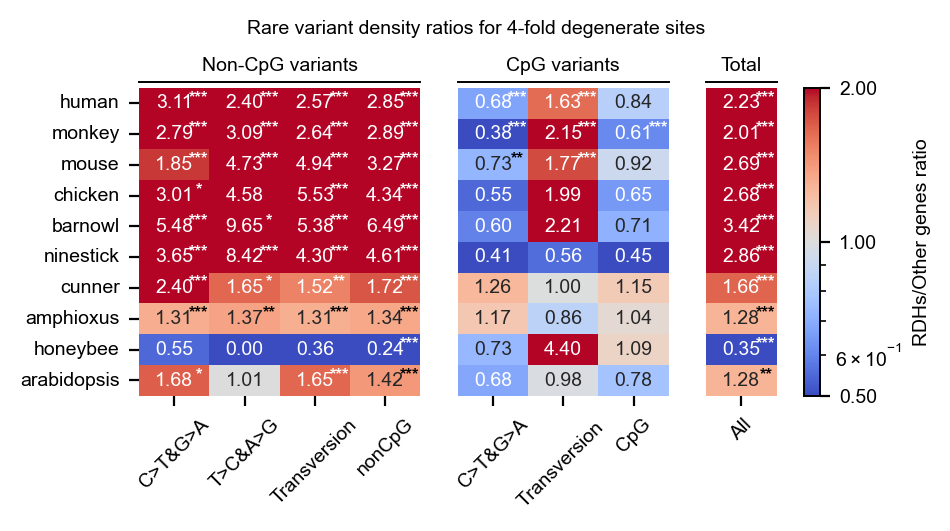

In [4]:
df_region = final_df.copy()

final_df_heatmap = df_region.pivot_table(
    index='species',
    columns='mutation',
    values='RDH/Other gene ratio',
    aggfunc='first'
)
p_value_heatmap = df_region.pivot_table(
    index='species',
    columns='mutation',
    values='p_value',
    aggfunc='first'
)

# Sort index
final_df_heatmap = final_df_heatmap.reindex(
    species_lst,
    axis=0
)
p_value_heatmap = p_value_heatmap.reindex(
    species_lst,
    axis=0
)

# Column groups (keep your original logic)
cols_non_cpg = [
    i for i in final_df_heatmap.columns
    if (('&' in i) or ('Transversion' in i)) and ('CpG' not in i)
] + ['nonCpG']
cols_cpg = [
    i for i in final_df_heatmap.columns
    if (('&' in i) or ('Transversion' in i)) and ('CpG' in i)
] + ['CpG']
cols_total = ['All']

# ---- 3. Prepare LogNorm and subplots ----
norm = LogNorm(vmin=0.5, vmax=2)

fig, axes = plt.subplots(
    1, 3, figsize=(4.5, len(species_lst)*0.2),
    width_ratios=[4, 3, 1],
    sharey=True
)

# Helper to plot one panel + stars
def plot_panel(ax, cols):
    if len(cols) == 0:
        ax.axis('off')
        return

    data = final_df_heatmap[cols]
    p_data = p_value_heatmap[cols]

    data_annot = data.copy()
    # Replace zeros to a small value for LogNorm
    data_color = data_annot.copy()
    data_color[data_color == 0] = 0.01

    # Draw the heatmap first
    sns.heatmap(
        data_color,
        annot=data_annot,
        # annot=True,
        fmt='.2f',
        cmap='coolwarm',
        norm=norm, cbar=False,
        ax=ax
    )

    nrows, ncols = data.shape
    cell_texts = np.array([float(i.get_text()) for i in ax.texts]).reshape(nrows, ncols)

    # Overlay significance stars
    for i in range(nrows):
        for j in range(ncols):
            pval = p_data.iloc[i, j]
            if pd.isna(pval):
                continue

            # Select star string
            if pval < 0.001:
                stars = '***'
            elif pval < 0.01:
                stars = '**'
            elif pval < 0.05:
                stars = '*'
            else:
                stars = ''

            if stars:
                ratio = cell_texts[i, j]
                star_color = 'white' if (ratio < 0.7) or (ratio > 1.5) else 'black'

                ax.text(
                    j + 0.85, i + 0.3, stars,
                    ha='center', va='center',
                    fontsize=6, color=star_color,
                    fontweight='bold'
                )

# Plot three panels
plot_panel(axes[0], cols_non_cpg)
plot_panel(axes[1], cols_cpg)
plot_panel(axes[2], cols_total)

# Refine axes
for idx, ax in enumerate(axes):
    ax.set_xticklabels(ax.get_xticklabels(), rotation=90)
    ax.set_xlabel('')
    if idx > 0:
        ax.set_ylabel('')
        ax.set_title('')
        ax.tick_params(axis='y', which='both', left=False, right=False)

# Refine x and y tick labels
axes[1].set_xticklabels(
    [label.get_text().replace('(CpG)', '') for label in axes[1].get_xticklabels()],
    rotation=90
)
axes[0].set_yticklabels(axes[0].get_yticklabels(), rotation=0)
for ax in axes:
    ax.plot([0, 1], [1.02, 1.02], color='black', linewidth=0.7,
            transform=ax.transAxes, clip_on=False)

# Colorbar
sm = ScalarMappable(norm=norm, cmap="coolwarm")
sm.set_array([])
cbar = fig.colorbar(
    sm,
    ax=axes,
    ticks=[0.5, 1, 2],
    format="%.2f",
    fraction=0.046,
    pad=0.04
)
cbar.set_label("RDHs/Other genes ratio")

axes[0].set_ylabel('')
axes[0].set_title('Non-CpG variants', fontsize=7)
axes[1].set_title('CpG variants', fontsize=7)
axes[2].set_title('Total', fontsize=7)

# axes x tick rotation 45
for ax in axes:
    plt.setp(ax.get_xticklabels(), rotation=45, ha='center')

fig.suptitle(f'Rare variant density ratios for 4-fold degenerate sites', y=1.05)